# Python Fundamentals — Portfolio Drift Monitor

**Stage 03 project contribution.** Demonstrates Python, NumPy and pandas on
**dummy data**, and documents the reusable functions now living in
`src/utils.py`.

No real market data is pulled here — that is Stage 04. Everything below is
simulated from a fixed seed so the notebook produces identical numbers on every
run.

In [1]:
# --- run me first: makes this notebook work wherever it lives ---
from pathlib import Path
import os, sys

if Path.cwd().name == 'notebooks':
    os.chdir('..')                      # project/notebooks -> project
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))       # so `from src.utils import ...` works

print('working from:', ROOT.name)

working from: project


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils import (TARGET_WEIGHTS, AMBER_PP, RED_PP,
                       clean_columns, parse_dates, to_weights, drift_pp, flag_drift)

print('targets:', TARGET_WEIGHTS, '| amber', AMBER_PP, 'pp | red', RED_PP, 'pp')

targets: {'VTI': 0.6, 'VXUS': 0.3, 'BND': 0.1} | amber 3.0 pp | red 5.0 pp


## 1. Python fundamentals — the objects the project is built from

The target allocation is a **dictionary**: fund ticker to target weight. Keys
carry meaning, order does not, and lookup is by name — exactly right for a
policy that a human sets and reads.

In [3]:
funds = list(TARGET_WEIGHTS.keys())
targets = np.array(list(TARGET_WEIGHTS.values()))

# A comprehension to render the policy as text, the way the memo states it.
print(', '.join(f"{k} {v:.0%}" for k, v in TARGET_WEIGHTS.items()))
print('weights sum to', sum(TARGET_WEIGHTS.values()))

VTI 60%, VXUS 30%, BND 10%
weights sum to 0.9999999999999999


## 2. Dummy data — 60 business days of prices

Generated, not downloaded. Share counts are chosen so that on day 0 the
portfolio sits exactly on target; every later deviation is caused purely by
price movement, which is the drift the monitor exists to catch.

In [4]:
rng = np.random.default_rng(11)          # seeded: same numbers every run

dates = pd.bdate_range('2025-01-02', periods=60)
start_prices = np.array([260.0, 62.0, 73.0])      # VTI, VXUS, BND

# Daily log-returns: equities more volatile than the bond fund.
steps = rng.normal(loc=[0.0006, 0.0003, 0.0001],
                   scale=[0.009, 0.010, 0.003],
                   size=(len(dates), len(funds)))
prices = start_prices * np.exp(np.cumsum(steps, axis=0))

PORTFOLIO_VALUE = 1_000_000
shares = (PORTFOLIO_VALUE * targets) / prices[0]   # day 0 sits exactly on target

prices_df = pd.DataFrame(prices, index=dates, columns=funds)
prices_df.head()

,VTI,VXUS,BND
2025-01-02,260.236118,62.867659,73.276034
2025-01-03,259.199129,62.699418,73.167509
2025-01-06,260.687961,62.683078,73.338969
2025-01-07,256.543494,63.691875,73.325088
2025-01-08,258.274151,63.624037,73.249067


## 3. NumPy — vectorized weights and drift

`values` is a 60x3 array. Dividing by the row sums gives every day's weights in
one operation, with no loop over days. This is the vectorization argument from
the reading applied to the actual problem.

In [5]:
values = prices * shares                          # elementwise, broadcasts across rows
weights = values / values.sum(axis=1, keepdims=True)

print('day 0 weights :', np.round(weights[0], 4), '<- exactly on target')
print('day -1 weights:', np.round(weights[-1], 4))

day 0 weights : [0.6 0.3 0.1] <- exactly on target
day -1 weights: [0.6345 0.2664 0.0991]


In [6]:
# Verify day 0 really is the target allocation.
assert np.allclose(weights[0], targets), "day 0 should sit exactly on target"
print('day 0 matches the 60/30/10 policy.')

day 0 matches the 60/30/10 policy.


## 4. pandas — the daily report

This is the artifact the memo promises Dana: one row per fund, with target,
current, drift in percentage points, and a flag.

In [7]:
latest = weights[-1]

report = pd.DataFrame({
    'fund': funds,
    'target_weight': targets,
    'current_weight': latest,
    'drift_pp': drift_pp(latest, targets),
})
report['flag'] = flag_drift(report['drift_pp'])
report.round(4)

,fund,target_weight,current_weight,drift_pp,flag
0,VTI,0.6,0.6345,3.4503,amber
1,VXUS,0.3,0.2664,-3.3605,amber
2,BND,0.1,0.0991,-0.0898,green


## 5. Weights over time

The table is one day. The chart is the history — and it is where a *drift* is
distinguishable from a *jump*.

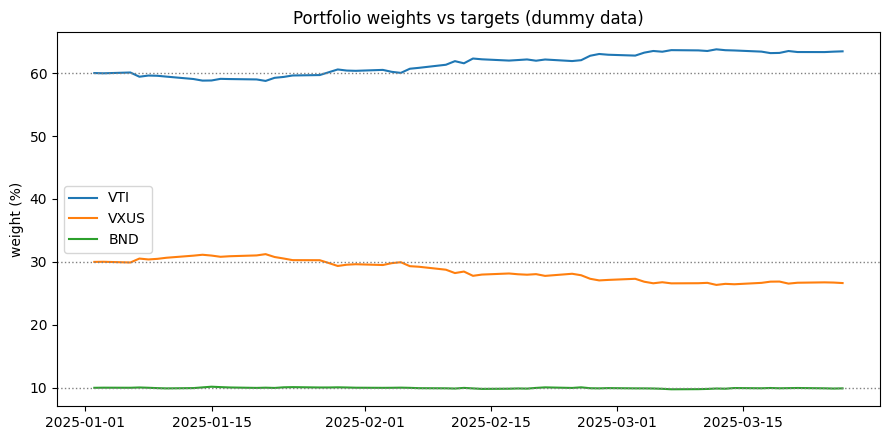

In [8]:
weights_df = pd.DataFrame(weights, index=dates, columns=funds)

fig, ax = plt.subplots(figsize=(9, 4.5))
for i, fund in enumerate(funds):
    ax.plot(weights_df.index, weights_df[fund] * 100, label=fund)
    ax.axhline(targets[i] * 100, linestyle=':', linewidth=1, color='grey')

ax.set_title('Portfolio weights vs targets (dummy data)')
ax.set_ylabel('weight (%)')
ax.legend(loc='center left')
fig.tight_layout()
plt.show()

## 6. The helper functions in `src/utils.py`

| Function | Takes | Returns | Why it exists |
|---|---|---|---|
| `clean_columns(df)` | a DataFrame | same data, snake_cased column names | vendor CSVs arrive with spaces and capitals; downstream code should not have to know which |
| `parse_dates(df, col)` | a DataFrame + column | dates as `datetime64`, or **raises** | a date that will not parse is a data-quality failure, not a `NaT` to carry forward |
| `to_weights(values)` | holdings values | weights summing to 1 | one definition of "weight" for the whole project |
| `drift_pp(current, target)` | two weight vectors | drift in **percentage points** | the reporting metric; pp not % is the distinction the memo turns on |
| `flag_drift(drift)` | drift in pp | green / amber / red | encodes the principal's 3pp/5pp policy in exactly one place |

Every one is pure — no disk writes, no mutation of its argument — so they are
safe to import anywhere and testable without fixtures.

In [9]:
# The guards are real, not decorative.
for bad_call, label in [
    (lambda: to_weights([0, 0, 0]),                 'to_weights with zero total'),
    (lambda: flag_drift([1.0], amber=9, red=2),     'flag_drift with amber > red'),
]:
    try:
        bad_call()
    except ValueError as e:
        print(f"{label:<32} -> ValueError: {e}")

to_weights with zero total       -> ValueError: total portfolio value must be positive
flag_drift with amber > red      -> ValueError: require 0 < amber <= red


In [10]:
# clean_columns and parse_dates, on a deliberately messy frame.
messy = pd.DataFrame({'  Fund Ticker ': ['VTI', 'BND'],
                      'Trade Date': ['2025-01-02', '2025-01-03'],
                      'Close Price': [260.0, 73.0]})
print('before:', list(messy.columns))

tidy = parse_dates(clean_columns(messy), col='trade_date')
print('after :', list(tidy.columns))
tidy.dtypes

before: ['  Fund Ticker ', 'Trade Date', 'Close Price']
after : ['fund_ticker', 'trade_date', 'close_price']


fund_ticker            object
trade_date     datetime64[ns]
close_price           float64
dtype: object

## Notes, assumptions, and what comes next

- **All data here is simulated.** Real VTI/VXUS/BND prices arrive in Stage 04
  via `project_pipeline.ipynb`, and land in `data/raw/`.
- **Share counts are fixed.** No deposits, withdrawals or rebalancing, so every
  weight change is price movement alone — consistent with the framing document's
  statement that this tracks the model portfolio, not a client account.
- **Weights come from prices only.** Accrued dividends are ignored; for a
  three-ETF model portfolio the effect is small but it is an assumption, not an
  omission.
- **The seed is fixed** (`default_rng(11)`), so this notebook is reproducible.
  Without it, every run would produce a different report and different chart.

**Next stage:** replace the simulated `prices` block with a real ingestion step,
keeping everything downstream of it unchanged. That is the test of whether these
functions were written at the right level of abstraction.